In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")



In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [18]:
urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents"

]

# docs1 = [WebBaseLoader(url).load() for url in urls]
# print("*" *10)
# print(docs1)
# print("*" *10)
docs= WebBaseLoader(urls).load()
print(docs)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestBackward compatibilityLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIs

In [20]:
# doc_list1 =[ item for sublist in docs1 for item in sublist]
# print("*"*10)
# print(doc_list1)

# doc_list2 =[ item for item in docs ]
# print("*"*10)
# print(doc_list2)

In [22]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
docs_split = text_splitter.split_documents(docs)
print(len(docs_split))

74


In [23]:
vectorstore = FAISS.from_documents(
    documents=docs_split,
    embedding=OpenAIEmbeddings()
)

retriever = vectorstore.as_retriever()

In [24]:
retriever.invoke("what is langgraph")

[Document(id='79e7e4ae-b1b7-4cef-be3c-5369c5422708', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bLangGraph ecosystem\nWhile LangGraph can be used standalone, it also integrates seamlessly with any LangChain product, giving developers a full suite of tools for building agents. To improve your LLM application development, pair LangGraph with:\nLangSmith ObservabilityTrace requests, evaluate outputs, and monitor deployments in one place. Prototype locally with LangGraph, then move to production with integrated observability and evaluation to build more reliable agent systems.Learn moreLangSmith DeploymentDeploy and scale agents effortlessly with a purpose-built deployment platform for long running, stateful workflows. Discover, reuse, configure, and share agents across

In [26]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="retriever_vector_db_blog",
    description="Search information about LangGraph"
)
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search information about LangGraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x71b3ec508670>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x71b3ec5089e0>)

### LangChain blogs in a different Vector STORE

In [27]:
urls2 = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/philosophy",
    "https://docs.langchain.com/oss/python/langchain/agents"
]

docs2= WebBaseLoader(urls2).load()
print(docs2)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext eng

In [28]:
docs2_split = text_splitter.split_documents(docs2)
print(len(docs2_split))

54


In [29]:
vectorstore_langchain = FAISS.from_documents(
    documents=docs2_split,
    embedding=OpenAIEmbeddings()
)

retriever_langchain = vectorstore_langchain.as_retriever()

In [30]:
retriever_tool_langchain = create_retriever_tool(
    retriever=retriever_langchain,
    name="retriever_vector__db_langchain_blog",
    description="Search and run information about LangChain"
)

In [31]:
tools = [retriever_tool, retriever_tool_langchain]

### LangGraph Workflow

In [33]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # the add_messages defines how an update should be processed
    # Default is to replace. add_messages says append
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [35]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")
llm.invoke("hi")

AIMessage(content='<think>\nOkay, the user said "hi". That\'s a greeting. I should respond in a friendly and welcoming way. Maybe start with a greeting and ask how I can assist them. Keep it open-ended so they feel comfortable to ask anything. Let me make sure the response is positive and approachable. Also, check for any typos or errors. Alright, ready to respond.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 9, 'total_tokens': 101, 'completion_time': 0.172435788, 'completion_tokens_details': None, 'prompt_time': 0.000216906, 'prompt_tokens_details': None, 'queue_time': 0.170035534, 'total_time': 0.172652694}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e331d-733c-7761-9f26-9dcab0991118-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=

In [36]:
def agent(state: AgentState):
    """
    Invokes the agent model to generate a response base on the current state.
    Given the question, it will decide to retrieve using the retriever tool. or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: the updated state with the agent response appended to messages
    """
    print("--- CALL AGENT ---")
    messages = state["messages"]
    model = llm
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

### create function to grade documents

In [49]:
### Edges
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import Literal


def grade_documents(state: AgentState) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state.

    Returns:
        str: A decision for wether the documents are relevant or not.
    """
    print("--- CHECK RELEVANCE ---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = llm

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)
    
    # Prompt - context comes from the vector store, question comes from user input
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of retrieved document to a user question.\n
        Here is the retrieved document:\n\n{context}\n\n
        Here is the question: \n\n{question}\n\n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.\n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the user question.
        """,
        input_variables=["context", "question"]
    )

    # Chain
    chain = prompt | llm_with_tool

    # Context and Question
    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content # this is que user input question
    docs = last_message.content # this is the context from the vector store

    # Pass the question and context to prompt and then to llm_with_tool to get a grade with binary_score with yes or no
    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("--- DECISION: DOCS RELEVANT ---")
        return "generate"
    else:
        print("--- DECISION: DOCS NOT RELEVANT ---")
        print(score)
        return "rewrite"


### create function to generate response

In [57]:
from langchain_core.output_parsers import StrOutputParser
from langsmith import Client

def generate(state:AgentState):
    """
    Generate answer.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated message
    """

    print("--- GENERATE ---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
            # "rlm/rag-prompt" is a pre-built third-party prompt template hosted on LangSmith Hub.
            # Format: "owner/prompt-name" — 'rlm' is the author (a LangChain core dev).
            # It fetches a standard RAG prompt with two variables: {question} and {context}.
            # You can view it at: https://smith.langchain.com/hub/rlm/rag-prompt
    client = Client()
    prompt = client.pull_prompt("rlm/rag-prompt:50442af1", dangerously_pull_public_prompt=True)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"question": question, "context": docs})
    return {"messages": [response]}


### create rewrite function

In [58]:
from langchain_core.messages import HumanMessage


def rewrite(state:AgentState):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("--- TRANSFORMATION QUERY ---")
    
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(content=f"""\n
        Look at the input and try to reason about the underlying semantic intent/meaning.\n
        Here is the initial question:
                    \n------\n
                    {question}
                    \n------\n
        Formulate an improved question:
        """)
    ]

    # Grader
    response = llm.invoke(msg)
    return {"messages": [response]}


### Create State Graph

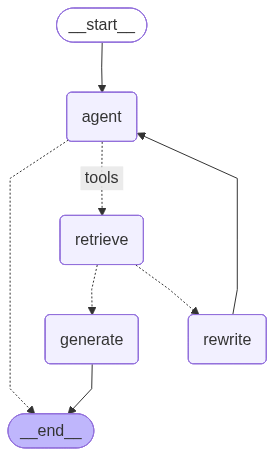

In [59]:
# Define a new graph
from IPython.display import Image,display
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


workflow = StateGraph(AgentState)

# Define nodes we will cycle between
workflow.add_node("agent", agent) # agent
retrieve = ToolNode([retriever_tool, retriever_tool_langchain])
workflow.add_node("retrieve", retrieve) # Retrieval
workflow.add_node("rewrite", rewrite) # Re-write the question
workflow.add_node("generate",generate) # Generating a response after we know the documents are relevant

# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in or graph
        "tools": "retrieve",
        END: END
    }
)

# Edges taken after the `action` node is called
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents
)

workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# compile
graph = workflow.compile()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [60]:
graph.invoke({"messages": "What is LangGraph"})

--- CALL AGENT ---
--- CHECK RELEVANCE ---
--- DECISION: DOCS RELEVANT ---
--- GENERATE ---


{'messages': [HumanMessage(content='What is LangGraph', additional_kwargs={}, response_metadata={}, id='b3fd3b92-cee4-45f8-99af-6a4f6ee987e3'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is LangGraph?" I need to figure out which tool to use here. Let me check the available functions. There\'s one called retriever_vector_db_blog which is for searching information about LangGraph. The other is for LangChain. Since the query is about LangGraph, the first function seems appropriate. I\'ll call that function with the query parameter set to "LangGraph".\n', 'tool_calls': [{'id': 'x9mz04vs3', 'function': {'arguments': '{"query":"LangGraph"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 113, 'prompt_tokens': 241, 'total_tokens': 354, 'completion_time': 0.18114231, 'completion_tokens_details': {'reasoning_tokens': 84}, 'prompt_time': 0.010492866, 'prompt_tokens_details': 

In [61]:
graph.invoke({"messages": "What is LangChain"})

--- CALL AGENT ---
--- CHECK RELEVANCE ---
--- DECISION: DOCS RELEVANT ---
--- GENERATE ---


{'messages': [HumanMessage(content='What is LangChain', additional_kwargs={}, response_metadata={}, id='3e779d74-f0f7-4434-a3aa-0ea3b8be727d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is LangChain?" I need to figure out which tool to use here. Let me check the available functions. There\'s one called retriever_vector_db_blog for LangGraph and another called retriever_vector__db_langchain_blog for LangChain. Since the user is asking about LangChain, the second function seems appropriate. I should call that function with the query "What is LangChain?" to get the necessary information. Let me make sure the parameters are correct. The function requires a "query" parameter, which I\'ll set to the user\'s question. Alright, I\'ll generate the tool call for the LangChain function.\n', 'tool_calls': [{'id': 'rz7hz9g39', 'function': {'arguments': '{"query":"What is LangChain?"}', 'name': 'retriever_vector__db_langchain_blog'}, 'type': 'fun

In [62]:
graph.invoke({"messages": "What is Machine Learning"})

--- CALL AGENT ---


{'messages': [HumanMessage(content='What is Machine Learning', additional_kwargs={}, response_metadata={}, id='1378ca6d-ba21-4a31-b1c8-37aad4a2b8d8'),
  AIMessage(content='Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to learn patterns and make decisions from data without being explicitly programmed for specific tasks. Instead of relying on hard-coded instructions, ML systems identify patterns in data and use these insights to improve their performance over time.\n\n### Key Concepts:\n1. **Supervised Learning**: Uses labeled data to train models (e.g., predicting house prices based on historical data).\n2. **Unsupervised Learning**: Finds hidden patterns in unlabeled data (e.g., grouping customers by purchasing behavior).\n3. **Reinforcement Learning**: Learns by interacting with an environment and receiving feedback in the form of rewards or penalties (e.g., training a robot to walk)

In [63]:
graph.invoke({"messages": "What is LsngChsinnn"})

--- CALL AGENT ---
--- CHECK RELEVANCE ---
--- DECISION: DOCS RELEVANT ---
--- GENERATE ---


{'messages': [HumanMessage(content='What is LsngChsinnn', additional_kwargs={}, response_metadata={}, id='d175fe82-3fdc-45ee-8b23-3fe8df2add9b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user asked, "What is LsngChsinnn?" Hmm, that\'s a bit confusing. Let me check if there\'s a typo there. They might have meant LangChain or LangGraph. Let me look at the available tools. There\'s a function for LangGraph and another for LangChain. I should probably search both to see if there\'s any info on "LsngChsinnn." Maybe it\'s a misspelling of LangChain. Let me use the retriever_vector_db_blog for LangGraph first, just in case. If that doesn\'t turn up anything, I can try the LangChain one. Wait, the user might have intended to ask about LangChain but made a typo. Let me check both sources. If neither has information, I\'ll let them know the term isn\'t recognized. Alright, let\'s start with the LangGraph function.\n', 'tool_calls': [{'id': 'b3qxnpnnp', 'function